In [278]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import xgboost as xgb 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# XGBoost
from xgboost import XGBClassifier





In [279]:

#loading dataset
df = pd.read_csv('customer.csv')
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')


In [280]:
#
print(df.head(5))
print("="*150)
print(df.shape)
print("="*150)
print(df.info())
print("="*150)
print(df.describe())
print("="*150)

#
print(df.drop_duplicates())
print("="*150)
print(df.isnull().sum())
print("="*150)

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4                18      0  
(6

In [281]:
#pruning
df.drop(columns=['CustomerID', 'Gender', 'Subscription Type'], inplace=True)


print(tabulate(df.info(), headers="keys", tablefmt="grid"))

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               64374 non-null  int64
 1   Tenure            64374 non-null  int64
 2   Usage Frequency   64374 non-null  int64
 3   Support Calls     64374 non-null  int64
 4   Payment Delay     64374 non-null  int64
 5   Contract Length   64374 non-null  str  
 6   Total Spend       64374 non-null  int64
 7   Last Interaction  64374 non-null  int64
 8   Churn             64374 non-null  int64
dtypes: int64(8), str(1)
memory usage: 4.4 MB



In [282]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [283]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, train_size=0.2, random_state=42, stratify=y
)


In [284]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (12874, 8)
Testing Features  : (51500, 8)
Training Target : (12874,)
Testing Target  : (51500,)


In [285]:
print(X_train["Contract Length"].unique())

<StringArray>
['Quarterly', 'Annual', 'Monthly']
Length: 3, dtype: str


In [286]:
categorical_features = X.select_dtypes(include=["object"]).columns

numerical_features = X.select_dtypes(exclude=["object"]).columns

print(categorical_features)

print(numerical_features)

Index(['Contract Length'], dtype='str')
Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction'],
      dtype='str')


C:\Users\saini\AppData\Local\Temp\ipykernel_23400\3373294906.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [287]:
#training model

model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Convert the string column to pandas categorical dtype for XGBoost
X_train = X_train.copy()
X_test = X_test.copy()


# Convert the string categorical feature to pandas category for XGBoost
categories = sorted(set(X_train["Contract Length"]).union(set(X_test["Contract Length"])))

X_train["Contract Length"] = pd.Categorical(X_train["Contract Length"], categories=categories)
X_test["Contract Length"] = pd.Categorical(X_test["Contract Length"], categories=categories)

model.set_params(enable_categorical=True)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [288]:
y_pred = model.predict(X_test)

In [289]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9412


In [290]:
comparison = X_test.copy()

comparison["Actual"] = y_test
comparison["Predicted"] = y_pred

print(comparison.head(20))

       Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
20539   53      31               29              0             10   
768     26      43               25              3              6   
7803    40      29               20              6             13   
26538   34      50               11              7             25   
63906   47      51               27              5             20   
24243   41      54               20             10             18   
39684   28       3               29              1             10   
48670   58      37               29              6             16   
15119   22      29                7             10              2   
43483   34      42               14              5             13   
4757    38       8               17              3             18   
63609   20      31               25              7             21   
6597    64      26               11              0              1   
51091   55      18               1

In [292]:


new_customer = pd.DataFrame({
    "Age": [35],
    "Tenure": [12],
    "Usage Frequency": [8],
    "Support Calls": [6],
    "Payment Delay": [20],
    "Contract Length": ["Monthly"],  # must match training categories
    "Total Spend": [450],
    "Last Interaction": [10]
})

new_customer["Contract Length"] = pd.Categorical(
    new_customer["Contract Length"],
    categories=X_train["Contract Length"].cat.categories
)
prediction = model.predict(new_customer)

print(prediction)

[0]


In [293]:
prediction = model.predict(new_customer)[0]
probability = model.predict_proba(new_customer)[0]

if prediction == 0:
    print("✅ Customer is likely to stay.")
    print(f"Confidence: {probability[0] * 100:.2f}%")
else:
    print("⚠️ Customer is likely to churn.")
    print(f"Confidence: {probability[1] * 100:.2f}%")

✅ Customer is likely to stay.
Confidence: 99.91%


In [294]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[25026  2079]
 [  948 23447]]


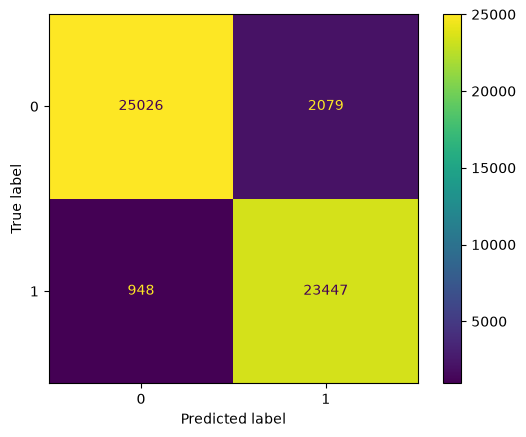

In [295]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [296]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94     27105
           1       0.92      0.96      0.94     24395

    accuracy                           0.94     51500
   macro avg       0.94      0.94      0.94     51500
weighted avg       0.94      0.94      0.94     51500



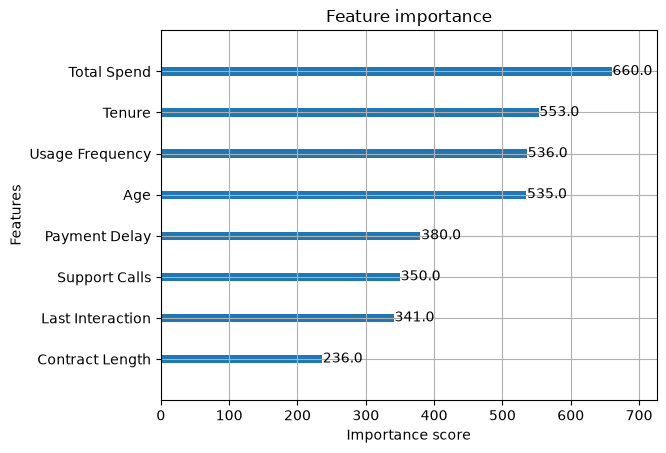

In [297]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)

plt.show()

In [298]:
model = XGBClassifier(
    n_estimators=10
)

In [299]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

estimators = [10, 25, 50, 100, 200, 300]

for n in estimators:

    model = XGBClassifier(
        n_estimators=n,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Trees = {n:3d} | Accuracy = {accuracy:.4f}")

Trees =  10 | Accuracy = 0.9486
Trees =  25 | Accuracy = 0.9481
Trees =  50 | Accuracy = 0.9433
Trees = 100 | Accuracy = 0.9412
Trees = 200 | Accuracy = 0.9388
Trees = 300 | Accuracy = 0.9379


In [300]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]

for lr in learning_rates:

    model = XGBClassifier(
        n_estimators=10,
        learning_rate=lr,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Learning Rate = {lr:.2f} | Accuracy = {accuracy:.4f}")

Learning Rate = 0.01 | Accuracy = 0.8928
Learning Rate = 0.05 | Accuracy = 0.9447
Learning Rate = 0.10 | Accuracy = 0.9468
Learning Rate = 0.20 | Accuracy = 0.9480
Learning Rate = 0.30 | Accuracy = 0.9486


In [301]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 8, 10]

for depth in depths:

    model = XGBClassifier(
        n_estimators=10,
        learning_rate=0.3,
        max_depth=depth,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Max Depth = {depth:2d} | Accuracy = {accuracy:.4f}")

Max Depth =  2 | Accuracy = 0.8776
Max Depth =  3 | Accuracy = 0.9350
Max Depth =  4 | Accuracy = 0.9381
Max Depth =  5 | Accuracy = 0.9454
Max Depth =  6 | Accuracy = 0.9486
Max Depth =  8 | Accuracy = 0.9473
Max Depth = 10 | Accuracy = 0.9429


In [302]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=10,
    learning_rate=0.3,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

final_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [303]:
y_pred = final_model.predict(X_test)

In [304]:
import joblib

joblib.dump(final_model, "customer_churn_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [305]:
loaded_model = joblib.load("customer_churn_model.pkl")

In [306]:
prediction = loaded_model.predict(new_customer)

print(prediction)

[0]
